In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

In [2]:
df = pd.read_csv('student-mat.csv', sep=';')
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [3]:
df['at_risk'] = (df['G3'] < 10).astype(int)

In [4]:
# List of columns to drop
cols_to_drop = [
    'school', 'address', 'famsize', 'Pstatus',
    'Mjob', 'Fjob', 'reason', 'guardian',
    'nursery', 'sex', 'age',
    'G3'
]

df_clean = df.drop(columns=cols_to_drop)
print("New shape:", df_clean.shape)

New shape: (395, 22)


In [5]:
TARGET = 'at_risk'

# All remaining columns except target are features
FEATURES = [col for col in df_clean.columns if col != TARGET]

print('Feature list:')
for i, f in enumerate(FEATURES, 1):
    print(f'  {i:02d}. {f}')

df_model = df_clean[FEATURES + [TARGET]].copy()
df_model.head(3)

Total features selected: 21

Feature list:
  01. Medu
  02. Fedu
  03. traveltime
  04. studytime
  05. failures
  06. schoolsup
  07. famsup
  08. paid
  09. activities
  10. higher
  11. internet
  12. romantic
  13. famrel
  14. freetime
  15. goout
  16. Dalc
  17. Walc
  18. health
  19. absences
  20. G1
  21. G2


,Medu,Fedu,traveltime,studytime,failures,schoolsup,famsup,paid,activities,higher,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,at_risk
0,4,4,2,2,0,yes,no,no,no,yes,...,4,3,4,1,1,3,6,5,6,1
1,1,1,1,2,0,no,yes,no,no,yes,...,5,3,3,1,1,3,4,5,5,1
2,1,1,1,2,3,yes,no,yes,no,yes,...,4,3,2,2,3,3,10,7,8,0


In [6]:
# Identify categorical columns in our selected feature set
cat_cols = df_model[FEATURES].select_dtypes(include='object').columns.tolist()
print(f'Categorical columns found: {cat_cols}')
df_model[cat_cols].head()

Categorical columns found: ['schoolsup', 'famsup', 'paid', 'activities', 'higher', 'internet', 'romantic']


,schoolsup,famsup,paid,activities,higher,internet,romantic
0,yes,no,no,no,yes,no,no
1,no,yes,no,no,yes,yes,no
2,yes,no,yes,no,yes,yes,no
3,no,yes,yes,yes,yes,yes,yes
4,no,yes,yes,no,yes,no,no


In [7]:
# yes/no columns
binary_cols = ['schoolsup', 'famsup', 'paid', 'activities', 'romantic', 'internet', 'higher']

for col in binary_cols:
    df_model[col] = df_model[col].map({'yes': 1, 'no': 0})

# check
df_model[binary_cols].head()

,schoolsup,famsup,paid,activities,romantic,internet,higher
0,1,0,0,0,0,0,1
1,0,1,0,0,0,1,1
2,1,0,1,0,0,1,1
3,0,1,1,1,1,1,1
4,0,1,1,0,0,0,1


In [8]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 22 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Medu        395 non-null    int64
 1   Fedu        395 non-null    int64
 2   traveltime  395 non-null    int64
 3   studytime   395 non-null    int64
 4   failures    395 non-null    int64
 5   schoolsup   395 non-null    int64
 6   famsup      395 non-null    int64
 7   paid        395 non-null    int64
 8   activities  395 non-null    int64
 9   higher      395 non-null    int64
 10  internet    395 non-null    int64
 11  romantic    395 non-null    int64
 12  famrel      395 non-null    int64
 13  freetime    395 non-null    int64
 14  goout       395 non-null    int64
 15  Dalc        395 non-null    int64
 16  Walc        395 non-null    int64
 17  health      395 non-null    int64
 18  absences    395 non-null    int64
 19  G1          395 non-null    int64
 20  G2          395 non-null    int6

In [12]:
class_counts = df_model[TARGET].value_counts()
imbalance_ratio = class_counts[0] / class_counts[1]

print(f'Passing  (0) : {class_counts[0]}')
print(f'At-Risk  (1) : {class_counts[1]}')
print(f'Imbalance ratio : {imbalance_ratio:.2f} : 1')


if imbalance_ratio > 1.5:
    print('Class imbalance detected -> SMOTE will be applied on training set')
else:
    print('Classes are relatively balanced')

Passing  (0) : 265
At-Risk  (1) : 130
Imbalance ratio : 2.04 : 1
Class imbalance detected -> SMOTE will be applied on training set


In [13]:
X = df_model[FEATURES]
y = df_model[TARGET]

# 80% train, 20% test — stratified to preserve class ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


After SMOTE:
Training set   : 424 samples (was 316)
Passing (0)    : 212
At-Risk (1)    : 212


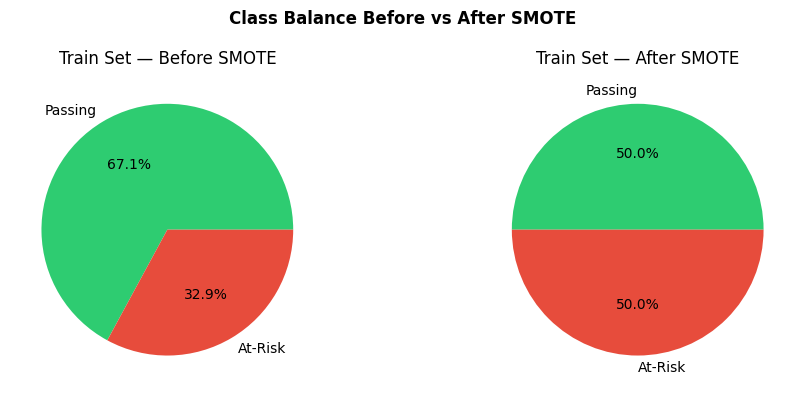

In [14]:
# Apply SMOTE only on training data
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print('After SMOTE:')
print(f'Training set   : {X_train_sm.shape[0]} samples (was {X_train.shape[0]})')
sm_counts = pd.Series(y_train_sm).value_counts()
print(f'Passing (0)    : {sm_counts[0]}')
print(f'At-Risk (1)    : {sm_counts[1]}')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
before = y_train.value_counts()
after = pd.Series(y_train_sm).value_counts()

axes[0].pie(before, labels=['Passing', 'At-Risk'],
            autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'])
axes[0].set_title('Train Set — Before SMOTE')

axes[1].pie(after, labels=['Passing', 'At-Risk'],
            autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'])
axes[1].set_title('Train Set — After SMOTE')

plt.suptitle('Class Balance Before vs After SMOTE', fontweight='bold')
plt.tight_layout()
plt.show()

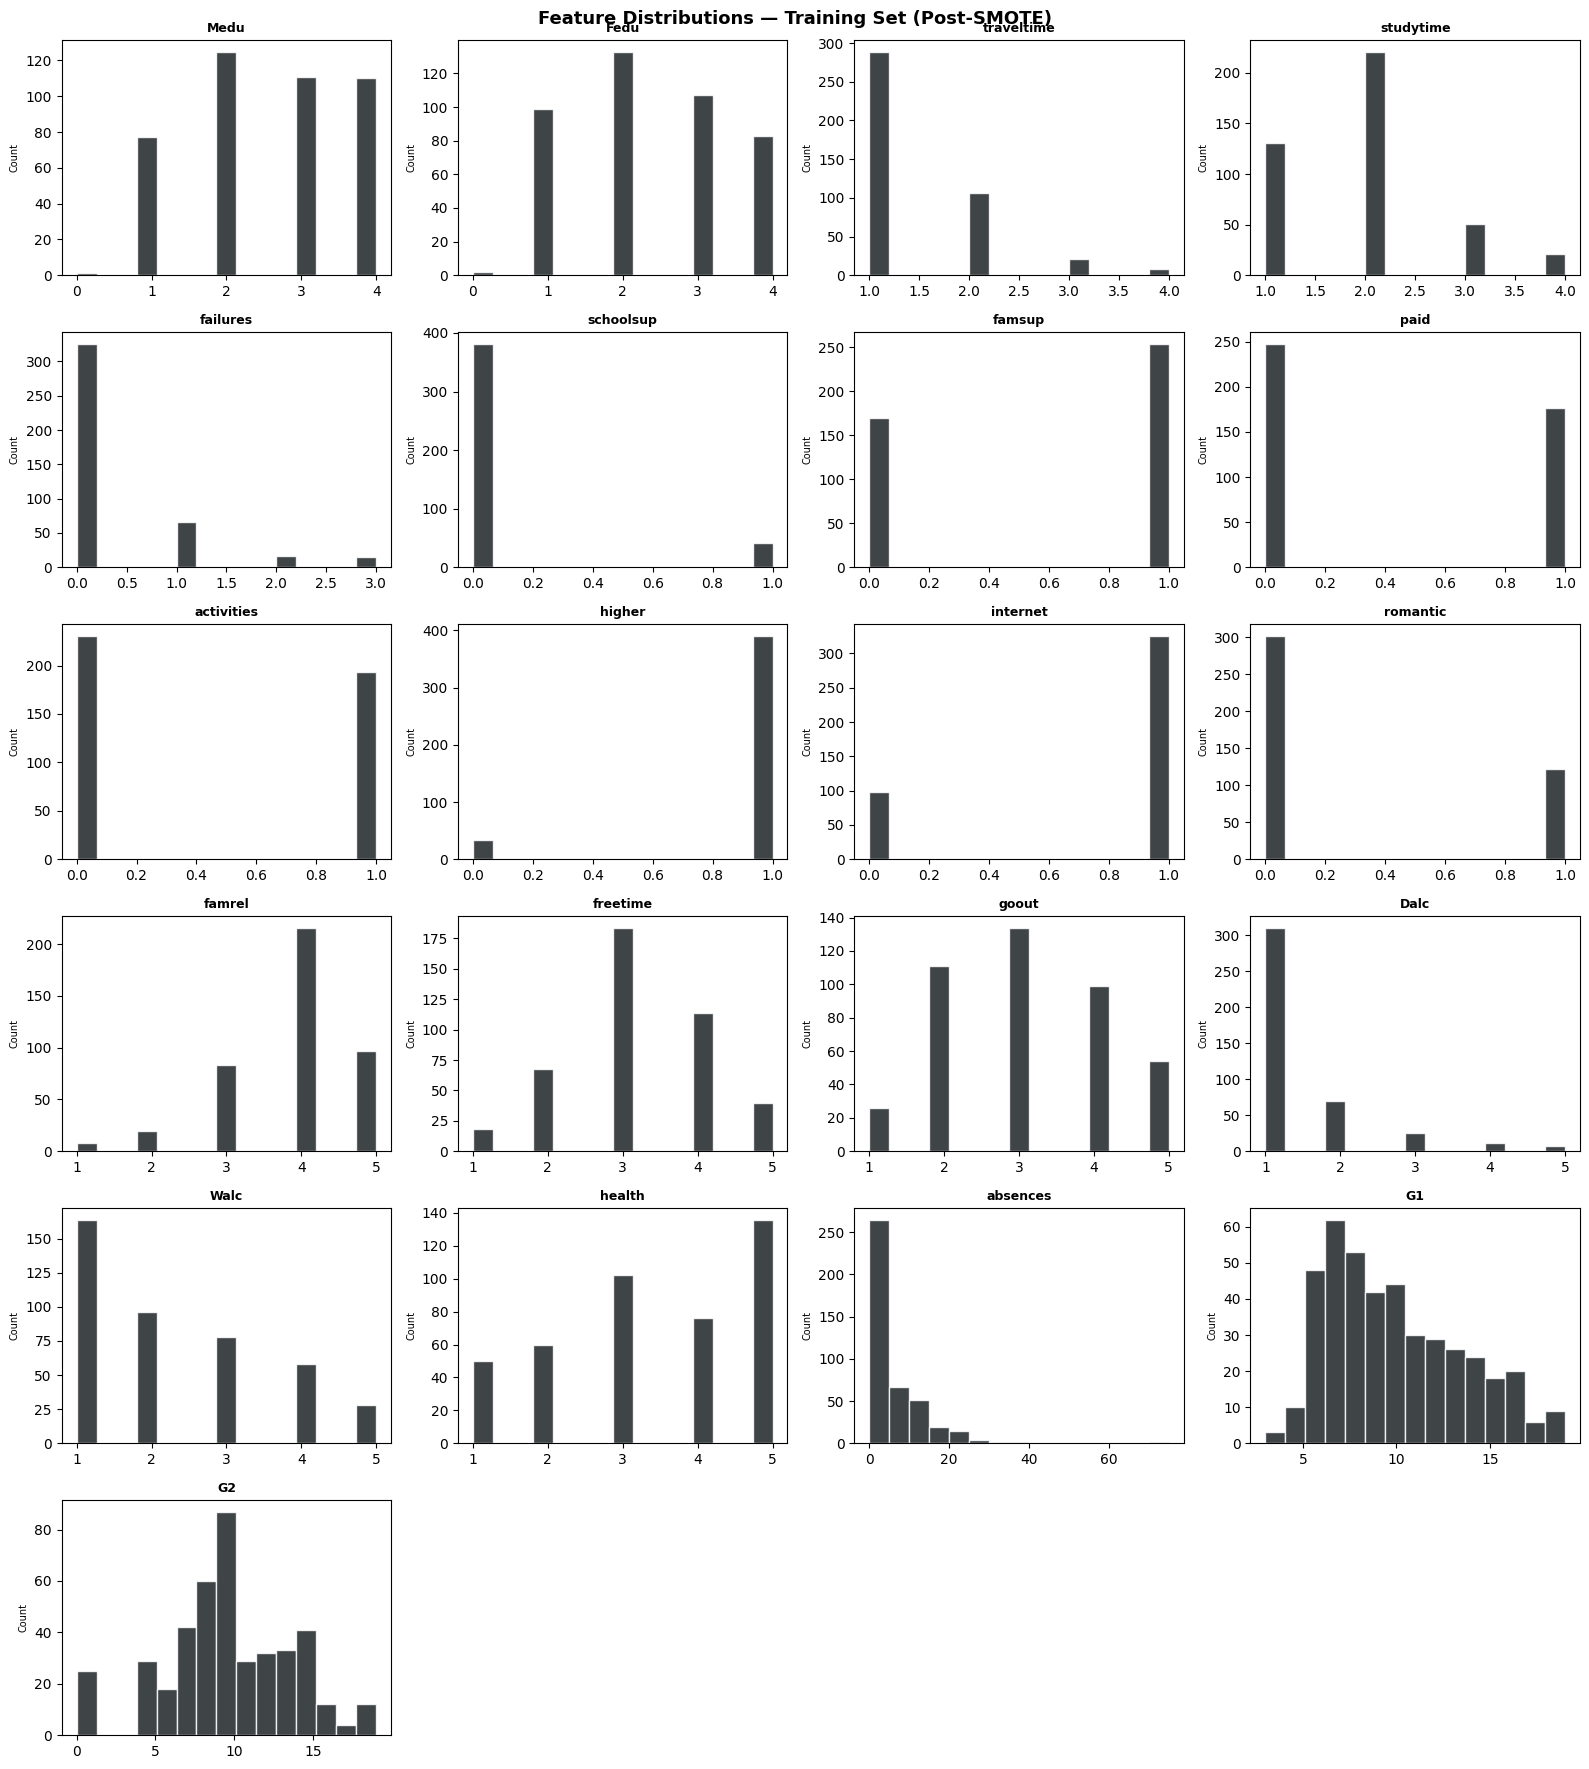

In [15]:
# Visual summary of feature distributions in final training set
X_train_df = pd.DataFrame(X_train_sm, columns=FEATURES)

n_cols = 4
n_rows = -(-len(FEATURES) // n_cols)  # ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(FEATURES):
    axes[i].hist(X_train_df[col], bins=15, color="#1d2327", edgecolor='white', alpha=0.85)
    axes[i].set_title(col, fontsize=9, fontweight='bold')
    axes[i].set_ylabel('Count', fontsize=7)

for j in range(len(FEATURES), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distributions — Training Set (Post-SMOTE)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [23]:
import os
os.makedirs('data/processed', exist_ok=True)

# Save train/test splits
X_train_df = pd.DataFrame(X_train_sm, columns=FEATURES)
X_test_df  = pd.DataFrame(X_test.values, columns=FEATURES)

X_train_df.to_csv('data/X_train.csv', index=False)
X_test_df.to_csv('data/X_test.csv', index=False)
pd.Series(y_train_sm, name='at_risk').to_csv('data/y_train.csv', index=False)
pd.Series(y_test.values, name='at_risk').to_csv('data/y_test.csv', index=False)

# Save feature list for use in model & API
import json
with open('data/features.json', 'w') as f:
    json.dump(FEATURES, f, indent=2)

